## __Week 6 Assignment: A/B Tests & Simple Linear Regression__

### __Topic 1: A/B Testing__

##### To implement A/B testing in Python, you primarily use `statsmodels` for frequentist tests (z-tests, t-tests) and `PyMC` for Bayesian analysis.

In [1]:
from statsmodels.stats.proportion import proportions_ztest

# Data: successes and total observations
count = [120, 145] # Conversions in Group A and B
nobs = [1000, 1000] # Total users in Group A and B

# Perform two-sided z-test
stat, p_value = proportions_ztest(count, nobs)

print(f"Z-statistic: {stat:.4f}, P-value: {p_value:.4f}")
if p_value < 0.05:
    print("Statistically significant result.")

Z-statistic: -1.6489, P-value: 0.0992


### __Question 1:__ 
A company wants to test if a new "Buy Now" button color (version B) increases sign-ups compared to the results above (for version A). After the trial was completed the results for Group A and B were updated to the following: 

#### Version B:
- __In Group A:__ (1,000 users), 120 signed up. 
- __In Group B:__ (1,000 users), 150 signed up. 

Now, use the `proportions_ztest` code above to determine if this 3% difference, in sign ups, is statistically significant at a 95% confidence level and what this means for your hypothesis. Include in your answer the new output from the code block as well.

In [2]:
count = [120, 150] # Conversions in Group A and B
nobs = [1000, 1000] # Total users in Group A and B

# Perform two-sided z-test
stat, p_value = proportions_ztest(count, nobs)

print(f"Z-statistic: {stat:.4f}, P-value: {p_value:.4f}")
if p_value < 0.05:
    print("Statistically significant result.")

Z-statistic: -1.9630, P-value: 0.0496
Statistically significant result.


Because the p-value for version B is below .05, this means that the 3% increase in signups is statistically significant at a 95% confidence level. Because it is statistically significant, we can reject the null hypothesis. In this instance, the null hypothesis would be that percentage of signups with the new button color is less than or equal to (i.e. does not increase) the percentage of signups with the original button.

### __Question 2:__
Can you explain the difference between a Type I error (false positive) and a Type II error (false negative) in the context of this test? 
- Extra points, if you can provide an explanation on the business impact each type would have in this scenario.

A Type 1 error would be if we rejected the null hypothesis, but it actually was the case that the new button color did not cause an increase in the percentage of sign-ups. If this were to happen for a business and they decided to release the new button, there are a few things that could happen: the new button could cause no change to the percentage of signups, or it could actually cause a decrease in the percentage of signups. 

A Type 2 error would be if we failed to reject the null hypothesis, yet it actually was the case that the new button color did cause an increase in the percentage of signups. In this case, if the business decided to not release the new button, then they likely would not realize this increased percentage of sign-ups (I say "likely" only because there is a chance that they could realize the increase percentage for a different reason).

### __Topic 2:__ Simple Linear Regression

Predicting how much a house costs based on its square footage.

In [8]:
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Data: Square footage (X) and House Price in thousands (y)
# X must be 2D: [[sqft1], [sqft2], ...]
X = np.array([[1000], [1500], [2000], [2500], [3000]])
y = np.array([200, 300, 400, 500, 600])

# 2. Initialize and Train the model
model = LinearRegression()
model.fit(X, y)

# 3. Predict the price for a 1800 sqft house
#new_house = np.array([[1800]])
new_house =([[1800]])
prediction = model.predict(new_house)

print(f"Predicted Price: ${prediction[0]:.3f}k")
print(f"R-squared Score: {model.score(X, y)}")


Predicted Price: $360.000k
R-squared Score: 1.0


### __Question 3:__
Swap X and y in the model.fit(X, y) line, would the code still run? What would the model be trying to predict then?

In [12]:
import numpy as np
from sklearn.linear_model import LinearRegression

X = np.array([[1000], [1500], [2000], [2500], [3000]])

y = np.array([200, 300, 400, 500, 600])

# 2. Initialize and Train the model
model = LinearRegression()
model.fit(y, X)

# 3. Predict the price for a 1800 sqft house
#new_house = np.array([[1800]])
new_house =([[1800]])
prediction = model.predict(new_house)

print(f"Predicted Price: ${prediction[0]:.3f}k")
print(f"R-squared Score: {model.score(X, y)}")

ValueError: Expected 2D array, got 1D array instead:
array=[200 300 400 500 600].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

No, the code does not run. Theoretically, if it were to run, then when you input 1800 for new house, the model would be trying to predict what the square footage of the house would be if the price was $1.8 million. I believe it does not run because the independent variable needs to be a 2D array, which "y" is not.

### __Question 4:__

How would you change the code to predict the prices for three different houses (1200, 2200, and 3500 sqft) all at once?

What is the new predicted price?

In [14]:
import numpy as np
from sklearn.linear_model import LinearRegression

X = np.array([[1000], [1500], [2000], [2500], [3000]])

y = np.array([200, 300, 400, 500, 600])

# 2. Initialize and Train the model
model = LinearRegression()
model.fit(X, y)

# 3. Predict the price for a 1800 sqft house
#new_house = np.array([[1800]])
new_house =([[1200], [2200], [3500]])
prediction = model.predict(new_house)

print(f"Predicted Price: ${prediction[0]:.3f}k")
print(f"Predicted Price: ${prediction[1]:.3f}k")
print(f"Predicted Price: ${prediction[2]:.3f}k")
print(f"R-squared Score: {model.score(X, y)}")

Predicted Price: $240.000k
Predicted Price: $440.000k
Predicted Price: $700.000k
R-squared Score: 1.0


The predicted prices are $240k for a 1,200 sqft house, $440k for a 2,200 sqft house, and $700k for a 3,500 sqft house.

### __Question 5:__

In the original code block the predicted house price for a 1800 sqft home was $360,000. This means the model discovered a perfect relationship (R^2 score = 1.0) where price = 0.2 x sqft or price = $200 per sqft.  

Now, add a house that is 5,000 sqft but only cost $100k (an outlier), how does this change the slope (line) this code creates? Compare the outputs for slope in your answer and how this is interpreted mathematically vs. in reality.

In [16]:
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Data: Square footage (X) and House Price in thousands (y)
# X must be 2D: [[sqft1], [sqft2], ...]
X = np.array([[1000], [1500], [2000], [2500],[3000]])
y = np.array([200, 300, 400, 500, 600])

# (New Code): Add Outlier Data
X_outlier = np.append(X, [[5000]], axis=0) # <---- Answer needed
y_outlier = np.append(y, [100]) # <---- Answer needed

# 2. Initialize and Train the model
model = LinearRegression()
model.fit(X, y)

# (New Code): Intialize, Train, and Fit Outlier Model
model_outlier = LinearRegression().fit(X_outlier, y_outlier) # <---- Answer needed

# 3. Predict the price for a 1800 sqft house
#new_house = np.array([[1800]])
#new_house =([[1800]])
#prediction = model.predict(new_house)

# Results
#print(f"Original Predicted Price: ${prediction[0]:.3f}k")
#print(f"Original R-squared Score: {model.score(X, y)}")
print(f"Original Slope: ${model.coef_[0]:.2f}")
print(f"Outlier Slope: {model_outlier.coef_[0]:.2f}")

Original Slope: $0.20
Outlier Slope: -0.02


When including the outlier, the slope becomes negative, as the original slope is positive. Mathematically, this new outlier slope would be interpreted to mean that price goes down as square footage increases. In reality, people know that this is not how housing prices work, so I would imagine that a data analyst would look back into their data and code to see where the problem is coming from. 

#### __Hint:__ If you are stuck, run this code below to see a visual of the slopes.

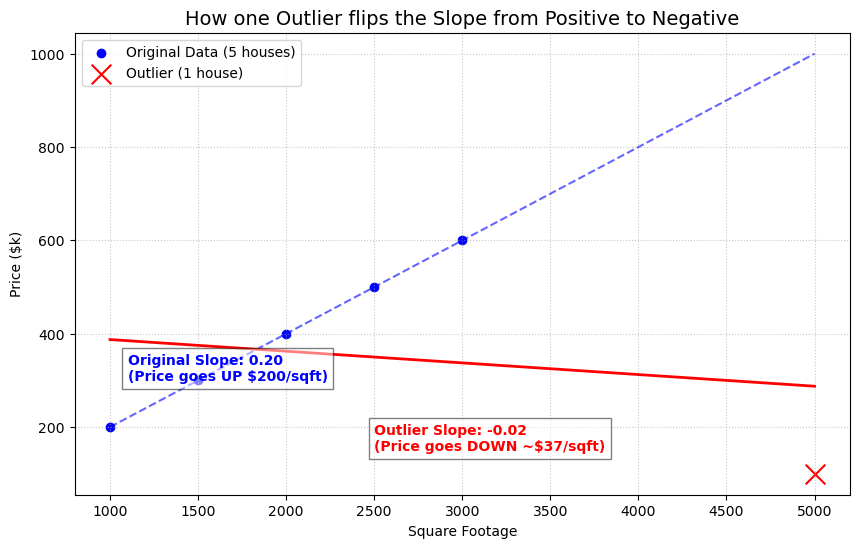

In [17]:
import matplotlib.pyplot as plt

# 1. Create a range for the lines
x_range = np.linspace(1000, 5000, 100).reshape(-1, 1)
y_line_orig = model.predict(x_range)
y_line_outlier = model_outlier.predict(x_range)

# 2. Extract the actual slope values from the models
slope_orig = model.coef_[0]
slope_outlier = model_outlier.coef_[0]

# 3. Create the plot
plt.figure(figsize=(10, 6))

# Plot data points
plt.scatter(X, y, color='blue', label='Original Data (5 houses)')
plt.scatter(X_outlier[-1], y_outlier[-1], color='red', marker='x', s=200, label='Outlier (1 house)')

# Plot regression lines
plt.plot(x_range, y_line_orig, color='blue', linestyle='--', alpha=0.6)
plt.plot(x_range, y_line_outlier, color='red', linewidth=2)

# 4. Display the Slopes as Text on the Graph
# Positioning the text near the start of the lines
plt.text(1100, 300, f"Original Slope: {slope_orig:.2f}\n(Price goes UP $200/sqft)", 
         color='blue', fontweight='bold', bbox=dict(facecolor='white', alpha=0.5))

plt.text(2500, 150, f"Outlier Slope: {slope_outlier:.2f}\n(Price goes DOWN ~$37/sqft)", 
         color='red', fontweight='bold', bbox=dict(facecolor='white', alpha=0.5))

# Formatting
plt.title("How one Outlier flips the Slope from Positive to Negative", fontsize=14)
plt.xlabel("Square Footage")
plt.ylabel("Price ($k)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()